# Sample orbit initial conditions from the distribution function of a DREAMS galaxy

The distribution function of a galaxy describes the probability of finding a star with given phase-space coordinates $(\bm{x},\bm{y})$. Assuming the system is spherically symmetric and a power-law form for the density profile, the position and velocity of particles bound to the system can be determined by:

1. obtaining the radial distance of particles from the center of the system using inverse transform sampling.

2. sampling, for each particle, the velocity distribution associated to that radius $p(v|r)$, which can be obtained from the distribution function of the galaxy using rejection sampling.





In [1]:
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from scipy.differentiate import derivative
import sys

sys.path.append("/mnt/home/asante/streams_in_dreams/")
import EXP4DREAMS

snap_path = "/mnt/home/dreams/ceph/Sims/CDM/MW_zooms/SB5/box_695/"
group_path = "/mnt/home/dreams/ceph/FOF_Subfind/CDM/MW_zooms/SB5/box_695/" 
output_path = "/mnt/home/asante/ceph/streams_test/"

### 1. Sample radii from a power-law density profile

Assume a spherical distribution of star particles all with the same mass $m$. The probability of finding a particle at a given distance $r$ is 

$$
p(r)~dr = \frac{4\pi r^2 n(r)~dr}{N},
$$

where $n(r)$ is the number density of particles at $r$ and $N$ is the total number of particles in the system. Multiplying by the mass of the particles, we have

$$
p(r)~dr = \frac{4\pi r^2~m~n(r)~dr}{mN} = \frac{4\pi r^2~\rho(r)~dr}{M}=\frac{dm}{M},
$$

where $\rho(r)$ is the mass density function and $M$ is the total mass of the system. Therefore, the corresponding cumulative distribution function CDF($r$), describing the probability of finding the particle anywhere in the galaxy within the radius $r$, can be thought as the fraction of the total mass enclosed in $r$, i.e.

$$
\mathrm{CDF}(r) = \frac{m(r'<r)}{M} = \frac{4\pi}{M} \int_{0}^{r} r'^2 \rho(r')dr' \tag{1}.
$$

If $\rho(r)$ is known, one can use inverse transform sampling to sample directly from $p(r)$. Assume $\rho(r)$ follows a power law behaviour $\rho(r) \propto r^{-\alpha}$, where $\alpha>0$. The CDF becomes:

$$
\mathrm{CDF}(r) = \frac{4\pi}{M} \int_{0}^{r} r'^{2-\alpha} dr'.
$$

Assume you are only interested in a region of the system, e.g. the stellar halo,  $r_{min}<r<r_{max}$. If we want to sample in this region, the original CDF needs to be multiplied by a new normalization constant such that $\mathrm{CDF}(r_{max}) = 1$. The new resulting CDF is

$$
\mathrm{CDF}(r) = \frac{3-\alpha}{r_{max}^{3-\alpha}-r_{min}^{3-\alpha}} \int_{r_{min}}^{r} r'^{2-\alpha} dr' \tag{2} = \frac{r^{3-\alpha}-r_{min}^{3-\alpha}}{r_{max}^{3-\alpha}-r_{min}^{3-\alpha}}, \;\; \mathrm{with} \, \alpha \neq 3.
$$

The corresponding inverse CDF is 

$$
\mathrm{CDF}^{-1}(u) = \left [ u~(r_{max}^{3-\alpha}-r_{min}^{3-\alpha}) + r_{min}^{3-\alpha}) \right]^{\frac{1}{3-\alpha}}, \tag{3}
$$

where $u\sim\mathcal{U}(0,1)$. By drawing random samples $u$, it is possible to use Eq. (3) to calculate the corresponding samples from $p(r)$ between $r_{min}$ and $r_{max}$.

Following the same derivation, when $\alpha=3$, we have:

$$
\mathrm{CDF}(r) = \frac{\ln{r} - \ln{r_{min}}}{\ln{r_{max}} - \ln{r_{min}}} \tag{4},
$$

and

$$
\mathrm{CDF}^{-1}(u) = r_{min}~\left(\frac{r_{max}}{r_{min}}\right)^u \tag{5}.
$$


In [2]:
import numpy as np

rng = np.random.default_rng(seed=16)

def sample_from_power_law_density_profile(
    n: int,
    r_min: float,
    r_max: float,
    alpha: int
    ):
    
    if alpha <= 0:
        raise ValueError("alpha must be a positive integer")
    
    elif alpha == 3:
        
        inv_cdf = lambda x: r_min * np.power( r_max/r_min, x)

    else:
        
        # For other values of alpha, use the general inverse CDF
        A = np.power(r_max, 3-alpha) - np.power(r_min, 3-alpha)
        B = np.power(r_min, 3-alpha)
        
        inv_cdf = lambda x: np.power( A*x + B, (1/(3-alpha)) )

    # Sample numbers from a uniform distribution
    U = rng.uniform(size=n)
    
    return inv_cdf(U)


               Scale Radius (DM): 		4.5 kpc
               Virial Radius: 		152.4 kpc
               Virial Mass: 		1e+12 M_sun
               Disc Scale Radius: 		2.1 kpc
               Disc Scale Height: 		0.5 kpc
               


Text(0, 0.5, 'PDF')

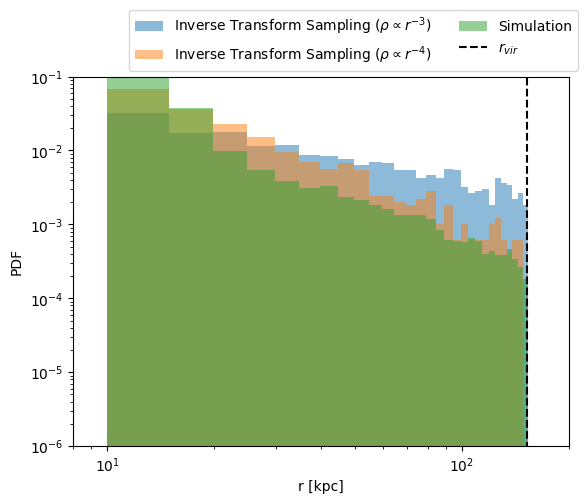

In [3]:
# Sample positions for 100 particles
# Load the Simulation data
MW_sim = EXP4DREAMS.DREAMSMW(snap_path=snap_path,
                             group_path=group_path)

stars = MW_sim.__load_part_data__(snap=90, PartType=4)
r_stars = stars['r']


r_sampled_3 = sample_from_power_law_density_profile(
    n=1000,
    r_min=10*u.kpc,
    r_max=MW_sim.r_vir*u.kpc,
    alpha=3
)

r_sampled_4 = sample_from_power_law_density_profile(
    n=1000,
    r_min=10*u.kpc,
    r_max=MW_sim.r_vir*u.kpc,
    alpha=4
)

import matplotlib.pyplot as plt
fig,ax = plt.subplots()

bins = np.linspace(10,500,100)


ax.hist(r_sampled_3.value, bins, density=True, alpha=0.5, label="Inverse Transform Sampling ($\\rho \propto r^{-3}$)")
ax.hist(r_sampled_4.value, bins, density=True, alpha=0.5, label="Inverse Transform Sampling ($\\rho \propto r^{-4}$)")
ax.hist(r_stars, bins, density=True, alpha=0.5, label="Simulation")

ax.set_xlim([8,200])
ax.set_ylim([1e-6,0.1])
ax.vlines(MW_sim.r_vir, 1e-10, 1, color="k", ls="--", label="$r_{vir}$")

ax.set_yscale('log')
ax.set_xscale('log')

ax.legend(bbox_to_anchor=(0.1, 1.2), loc='upper left', ncols = 2)
ax.set_xlabel("r [kpc]")
ax.set_ylabel("PDF")


### 2. Sampling $p(v|r)$ with Eddington's formula

For a stellar system in a spherical potential, the distribution function can be derived directly from the hamiltonian of the system using **Eddington's formula** (Eq. 4.46a in Binney & Tremaine's Galactic Dynamics):

$$
f(\mathcal{E}) = \frac{1}{\sqrt{8}\pi^2} \left[ \int_0^{\mathcal{E}} \frac{d^2\rho}{d\Psi^2} \frac{d\Psi}{\sqrt{\mathcal{E} - \Psi}} + \frac{1}{\sqrt{\mathcal{E}}} \left( \frac{d\rho}{d\Psi} \right)_{\Psi=0} \right],
$$

where $\epsilon = - \Psi - \frac{1}{2}v^{2} + \Psi_{0}$ is the relative energy of the particles and $\Psi_{0}$ is a constant term which ensures that $f>0$ for $\epsilon>0$ and $f=0$ when $\epsilon \leq 0$.

For most physically realistic galaxies where density smoothly approaches zero at infinity (where $\Psi \to 0$), the boundary term vanishes, simplifying the equation to:

$$
f(\mathcal{E}) = \frac{1}{\sqrt{8}\pi^2} \int_0^{\mathcal{E}} \frac{d^2\rho}{d\Psi^2} \frac{d\Psi}{\sqrt{\mathcal{E} - \Psi}}.
$$

Using subsitution of variables $u=\sqrt{\mathcal{E} - \Psi}$, the integral becomes:

$$
f(\mathcal{E}) = \frac{1}{\sqrt{2}\pi^2} \int_0^{\sqrt{\mathcal{E}}} \frac{d^2\rho}{d\Psi^2} du. \tag{6}
$$


In our scenario, the density and potential fields of the galaxy are approximated across a radial grid using basis-function expansion with $\mathtt{EXP}$. Therefore, $\rho$, $\Psi$, and $\mathcal{E}$ are all functions of the positions ($\bm{x}$) and velocities ($\bm{v}$) of the particles in the simulation. Therefore, it makes sense to re-write $\frac{d^2\rho}{d\Psi^2}$ and all the calculation inside the integral as a function of $r$.  



In [4]:
z_range = [1,0]

basis_dict = {# PartType : basis params 
                1: {"Lmax": 6, "nmax": 20, "numr": 2000, "rmin": 0.001, "rmax":1.5},
                4: {"mmax": 6, "nmax": 12 }
                }
density_dict = {1: {"bins": 500, 
                    "rangevals": [0.1, 100] 
                    },
                4: {}
                }

# Load the Simulation data
MW_sim = EXP4DREAMS.DREAMSMW(snap_path=snap_path,
                             group_path=group_path)

# Perform EXP expansion
EXP_gen = EXP4DREAMS.EXPBFE_builder(sim=MW_sim,
                                    basis_params_dict=basis_dict,
                                    density_dict=density_dict,
                                    z_range=z_range,
                                    output_dir=output_path)

# Create Gala-EXP potential object
pot, exp_units = EXP_gen.build_gala_potential()


               Scale Radius (DM): 		4.5 kpc
               Virial Radius: 		152.4 kpc
               Virial Mass: 		1e+12 M_sun
               Disc Scale Radius: 		2.1 kpc
               Disc Scale Height: 		0.5 kpc
               
Indexing snapshot directory...
Found 5 snapshots in range [1, 0] (Snap 61 to 90)
Snapshots used for the expansion: 61 to 90
Building basis for the expansion...
! Scaling:  R= 0.6514448938042994   M= 1.0
1.0 1.4436769529029623 1.4436769529029623 1.4436769529029623
{'id': 'sphereSL', 'parameters': {'numr': 2000, 'rmin': 0.001, 'rmax': 1.5, 'Lmax': 6, 'nmax': 20, 'rmapping': 0.02931458978538835, 'modelname': '/mnt/home/asante/ceph/streams_test/basis_empirical_PartType1.txt', 'cachename': '/mnt/home/asante/ceph/streams_test/basis_empirical_PartType1.cache.run0', 'pcavar': True, 'subsamp': 1000}, 'runtag': 'run0'}


---- SLGridSph::ReadH5Cache: error reading </mnt/home/asante/ceph/streams_test/basis_empirical_PartType1.cache.run0>
---- SLGridSph::ReadH5Cache: HDF5 error is <Unable to open file /mnt/home/asante/ceph/streams_test/basis_empirical_PartType1.cache.run0 (File accessibility) Unable to open file>


---- SLGridSph::WriteH5Cache: wrote </mnt/home/asante/ceph/streams_test/basis_empirical_PartType1.cache.run0>
---- Spherical::orthoTest: worst=0.000977564
{'id': 'cylinder', 'parameters': {'acyl': 0.013667086195271792, 'hcyl': 0.00296660882702549, 'lmaxfid': 32, 'nmaxfid': 32, 'mmax': 6, 'nmax': 12, 'ncylnx': 256, 'ncylny': 128, 'ncylodd': 3, 'rnum': 1000, 'pnum': 0, 'tnum': 80, 'ashift': 0.5, 'vflag': 16, 'logr': False, 'cachename': '/mnt/home/asante/ceph/streams_test/basis_empirical_PartType4.cache.run0', 'pcavar': True, 'subsamp': 1000}}
---- EmpCylSL cache parameter ascl: wanted 0.0136671 found 0.0136671
---- DiskType is <exponential>
---- pyEXP uses sech^2(z/h) rather than the more common sech^2(z/(2h))
---- Use the 'sech2: true' in your YAML config to use sech^2(z/(2h))
---- pyEXP will assume sech^2(z/(2h)) by default in v 7.9.0 and later
---- EmpCylSL::make_sl(): making SLGridSph with <Exponential> model
---- EmpCylSL[SLGridSph]: biorthogonal check passed
Process    0: Begin com

Worker    0: tables allocated, MMAX=6
---- EmpCylSL::cache_grid: HDF5 parameter mismatch


Snapshot 62 not found
Snapshot 63 not found
Snapshot 64 not found
Snapshot 65 not found
Snapshot 66 not found
Snapshot 68 not found
Snapshot 69 not found
Snapshot 70 not found
Snapshot 71 not found
Snapshot 72 not found
Snapshot 74 not found
Snapshot 75 not found
Snapshot 76 not found
Snapshot 77 not found
Snapshot 78 not found
Snapshot 79 not found
Snapshot 80 not found
Snapshot 82 not found
Snapshot 83 not found
Snapshot 84 not found
Snapshot 85 not found
Snapshot 86 not found
Snapshot 87 not found
Snapshot 88 not found
Snapshot 89 not found
Time taken for PartType 1: 1.01 minutes
Snapshot 62 not found
Snapshot 63 not found
Snapshot 64 not found
Snapshot 65 not found
Snapshot 66 not found
Snapshot 68 not found
Snapshot 69 not found
Snapshot 70 not found
Snapshot 71 not found
Snapshot 72 not found
Snapshot 74 not found
Snapshot 75 not found
Snapshot 76 not found
Snapshot 77 not found
Snapshot 78 not found
Snapshot 79 not found
Snapshot 80 not found
Snapshot 82 not found
Snapshot 83 no

Worker    0: tables allocated, MMAX=6


---- Spherical::orthoTest: worst=0.000977564
---- EmpCylSL::ReadH5Cache: read </mnt/home/asante/ceph/streams_test/basis_empirical_PartType4.cache.run0>
---- EmpCylSL::read_cache: table forwarded to all processes
---- Cylindrical::orthoTest: worst=9.05758e-05


In [5]:
# Density function from EXP
def rho(r):
    
    basis = EXP_gen.basis[1]
    coefs = EXP_gen.coefs[1]
    
    # Load basis coefficients
    basis.set_coefs(coefs.getCoefStruct(EXP_gen.coefs[1].Times()[-1]))
    idx = basis.getFieldLabels().index("dens")
    
    r_flat = np.asarray(r).flatten()
    vals = []
    for xi in r_flat:
        vals.append(basis.getFields(xi, 0.0, 0.0)[idx])
        
    return np.array(vals).reshape(np.shape(r))
    
# Potential function EXP
def psi(r):
    
    basis = EXP_gen.basis[1]
    coefs = EXP_gen.coefs[1]
    
    # Load basis coefficients
    basis.set_coefs(coefs.getCoefStruct(EXP_gen.coefs[1].Times()[-1]))
    idx = basis.getFieldLabels().index("potl")
    
    r_flat = np.asarray(r).flatten()
    vals = []
    for xi in r_flat:
        vals.append(basis.getFields(xi, 0.0, 0.0)[idx])
        
    return np.array(vals).reshape(np.shape(r))
 
    
def epsilon(r, v, phi0=0.):

    # Compute the relative energy at radius r
    H = psi(r) + 0.5*v*v
    
    return - H - phi0



The first derivative of density with respect to the potential is expanded via the chain rule as:
$$
\frac{d\rho}{d\Psi} = \frac{d\rho/dr}{d\Psi/dr} = \frac{\rho'(r)}{\Psi'(r)}
$$.

The differential in the potential is transformed in terms of the radial position as:

$$
\frac{d}{d\Psi} = \left ( \frac{d\Psi}{dr} \right)^{-1} \, \frac{d}{dr} = \Psi'(r)^{-1} \frac{d}{dr}.
$$

Therefore, the second derivative term becomes:

$$

\frac{d^2\rho}{d\Psi^2} = \frac{\rho''(r) \, \Psi'(r) - \rho'(r) \, \Psi''(r)}{\Psi'(r)^3} \tag{7}

$$

The term $\Psi'(r)$ correspond to the radial force acting to the particles, i.e. $\Psi'(r)=-F_{rad}(r)$  and is estimated directly from the $\texttt{EXP}$ basis function expansions, while the terms $\rho'(r)$, $\rho''(r)$, and $\Psi''(r)$ can be estimated using numerical methods starting from the $\texttt{EXP}$ evaluation of the potential and density fields.

In [49]:
def drho_dr(r):
    
    basis = EXP_gen.basis[1]
    coefs = EXP_gen.coefs[1]
    
    # Load basis coefficients
    basis.set_coefs(coefs.getCoefStruct(EXP_gen.coefs[1].Times()[-1]))
    idx = basis.getFieldLabels().index("dens")
    
    
    def dens_fn(x):
        # 1. Flatten SciPy's multi-dimensional step arrays into a safe 1D list
        x_flat = np.asarray(x).flatten()
        vals = []
        
        for xi in x_flat:
            
            vals.append(basis.getFields(xi, 0.0, 0.0)[idx])
                
        # 4. Reshape the flat results back to the exact shape SciPy needs
        return np.array(vals).reshape(np.shape(x))
    
    
    derivative_results = derivative(dens_fn, 
                                    r,
                                    maxiter=100,
                                    initial_step=(0.1*u.kpc).to(exp_units['length']).value
                                    )

    
    return derivative_results.df

def dpsi_dr(r):
    # This is just the radial force, which can be directly obtained from EXP
    basis = EXP_gen.basis[1]
    coefs = EXP_gen.coefs[1]
    
    # Load basis coefficients
    basis.set_coefs(coefs.getCoefStruct(EXP_gen.coefs[1].Times()[-1]))
    idx = basis.getFieldLabels().index("rad force")
    
    r_flat = np.asarray(r).flatten()
    vals = []
    for xi in r_flat:
        vals.append(- basis.getFields(xi, 0.0, 0.0)[idx])
        
    return np.array(vals).reshape(np.shape(r))
    
# The second derivative of the density and potential fields are computed numerically
def drho2_dr2(r):
    
    basis = EXP_gen.basis[1]
    coefs = EXP_gen.coefs[1]
    
    # Load basis coefficients
    basis.set_coefs(coefs.getCoefStruct(EXP_gen.coefs[1].Times()[-1]))
    idx = basis.getFieldLabels().index('dens')
    
    def get_field_derivative(r):
    
        def dens_fn(x):
            # 1. Flatten SciPy's multi-dimensional step arrays into a safe 1D list
            x_flat = np.asarray(x).flatten()
            vals = []
            
            for xi in x_flat:
                
                vals.append(basis.getFields(xi, 0.0, 0.0)[idx])
                    
            # 4. Reshape the flat results back to the exact shape SciPy needs
            return np.array(vals).reshape(np.shape(x))
    
    
        derivative_results = derivative(dens_fn, 
                                        r,
                                        maxiter=100,
                                        initial_step=(0.1*u.kpc).to(exp_units['length']).value
                                        )
        
        return derivative_results.df
    
    
    derivative_results = derivative(get_field_derivative,
                                    r,
                                    maxiter=100,
                                    initial_step=(0.1*u.kpc).to(exp_units['length']).value
                                    )
    
    return derivative_results.df

def dpsi2_dr2(r):
        
    basis = EXP_gen.basis[1]
    coefs = EXP_gen.coefs[1]
    
    # Load basis coefficients
    basis.set_coefs(coefs.getCoefStruct(EXP_gen.coefs[1].Times()[-1]))
    idx = basis.getFieldLabels().index("rad force")
    
    
    def dens_fn(x):
        # 1. Flatten SciPy's multi-dimensional step arrays into a safe 1D list
        x_flat = np.asarray(x).flatten()
        vals = []
        
        for xi in x_flat:
            
            vals.append(- basis.getFields(xi, 0.0, 0.0)[idx])
                
        # 4. Reshape the flat results back to the exact shape SciPy needs
        return np.array(vals).reshape(np.shape(x))
    
    
    derivative_results = derivative(dens_fn, 
                                    r,
                                    maxiter=100,
                                    initial_step=(0.1*u.kpc).to(exp_units['length']).value
                                    )

    
    return derivative_results.df

def drho2_dpsi2(r):
    
    numerator = drho2_dr2(r) * dpsi_dr(r) - drho_dr(r) * dpsi2_dr2(r) 
    denominator = dpsi_dr(r)**3 + 1e-12
    
    return numerator / denominator

Having a function that calculates $\frac{d^2\rho}{d\Psi^2}$ at any given radial position $r$, and knowing that the potential $\Psi(r)$ is a monotonic function of $r$, we can use cubic splines to create a new function $\mathcal{F}(\Psi(u)) \equiv \frac{d^2\rho}{d\Psi^2}$ which relates directly the value of the second derivative (Eq. 7) to the value of the potential at each $r$. This function can then be used to numerically estimate the value of the integral:

$$
f(\mathcal{E}) = \frac{1}{\sqrt{2}\pi^2} \int_0^{\sqrt{\mathcal{E}}} \mathcal{F}(\Psi(u))  du.
$$


In [50]:
from scipy.interpolate import CubicSpline
from scipy.integrate import quad

r_grid = np.logspace(-5, 1, 1000)

potential_values = psi(r_grid)
second_derivative_values = drho2_dpsi2(r_grid)
 
second_derivative_spline = CubicSpline(potential_values, second_derivative_values, extrapolate=True)

def evaluate_df(r,v_mag):
    
    eps = epsilon(r, v_mag)
    
    def integrand(u):
        psi_val = eps - u**2
        return second_derivative_spline(psi_val)
    
    # Perform the integration using numerical integration
    integral_val, _ = quad(integrand, 0, np.sqrt(eps))
        
    return - integral_val / (np.sqrt(2) * np.pi**2)


At each radial position, it is possible to sample a velocity vector which is consistent with the overall distribution function of the galaxy, determined from Eddington's formula. From the definition of conditional probability, we have:

$$
p(\mathbf{v}|\mathbf{r}) = \frac{p(\mathbf{v},\mathbf{r})}{p(\mathbf{r})}, \; \text{where} \; p(\mathbf{v}|\mathbf{r}) \equiv f(\mathcal{E}).
$$

As $f(\mathcal{E})$ only depends on the speed of a particle, so you can integrate over the full solid angle in the velocity space:

$$
p(v|\mathbf{r})~dv \propto 4\pi \, v^2 f(\mathcal{E}) \, dv. 
$$


Therefore, at each radial position $r$, we can sample a velocity at random $v\sim U(0,v_{circ})$, where $v_{circ}$ is the circular velocity at $r$, and use rejection sampling to approximate the distribution $p(v|\mathbf{r})$.

In [51]:
from scipy.optimize import minimize_scalar

class VelocitySampler:
    """
    A class to pre-compute the target PDF and efficiently sample velocities 
    using vectorized rejection sampling.
    """
    def __init__(self, r, v_esc, df_function):
        self.r = r
        self.v_esc = v_esc
        self.df_function = np.vectorize(df_function)
        
        # Calculate the maximum of the PDF *before* any sampling occurs
        self.max_pdf = self._compute_max_pdf()

    def _target_pdf(self, v):
        """The unnormalized probability density: v^2 * f(E)"""
        # Ensure v doesn't exceed v_esc to prevent unphysical values
        v = np.clip(v, 0, self.v_esc)
        return (v**2) * self.df_function(self.r, v)

    def _compute_max_pdf(self):
            
        # minimize_scalar looks for a minimum, so we pass the negative PDF
        res = minimize_scalar(
            lambda v: -self._target_pdf(v), 
            bounds=(0, self.v_esc), 
            method='bounded'
        )
        
        # Return the positive maximum, adding a 1% buffer for floating point safety
        return -res.fun * 1.01

    def sample(self, n_particles=1):
        """
        Draws n_particles using vectorized rejection sampling.
        """

        accepted_samples = []
        
        # Loop until we have accepted the requested number of particles
        while len(accepted_samples) < n_particles:
            
            # How many more particles do we need?
            n_needed = n_particles - len(accepted_samples)
            
            # Step A & B: Vectorized proposal of velocities and uniform heights
            # We draw a few extra to account for rejected samples
            v_prop = rng.uniform(0, self.v_esc, size=int(n_needed * 1.5))
            u = rng.uniform(0, 1, size=len(v_prop))
            
            # Step C: Evaluate the target PDF for all proposed velocities at once
            pdf_values = self._target_pdf(v_prop) / self.max_pdf
            
            # Boolean array of which samples fell under the curve
            accepted_mask = u <= pdf_values
            
            # Filter and append the accepted velocities
            valid_v = v_prop[accepted_mask]
            accepted_samples.extend(valid_v)

        # Return exactly the requested number of samples as a numpy array
        return np.array(accepted_samples[:n_particles])

In [116]:
def make_isotropic_vectors(
    mag,
    rng = None
    ):
    
    
    if rng is None:
        rng = np.random.default_rng(42)

    theta = np.arccos(rng.uniform(-1, 1, size=len(mag)))
    phi = np.random.uniform(0, 2*np.pi, size=len(mag))

    x = mag * np.sin(theta) * np.cos(phi)
    y = mag * np.sin(theta) * np.sin(phi)
    z = mag * np.cos(theta)
    
    return np.array([x, y, z])*mag.unit

# Calculate the circular velocity at radius r
pos_vector = make_isotropic_vectors(r_sampled_4, rng=rng)
v_circ = pot.circular_velocity(pos_vector.to(exp_units['length']).value, 
                                t=EXP_gen.coefs[1].Times()[-1]).value

v_sampled = []

for r, v in zip(r_sampled_4, v_circ):
    
    try:
        unit = r.unit
    except AttributeError:
        unit = None

    if unit is not None:
        r = r.to(exp_units['length']).value

    v_sampler = VelocitySampler(
        r=r, 
        v_esc=v, 
        df_function=evaluate_df)
    
    # Sample velocities
    v_sampled.extend(v_sampler.sample(10))

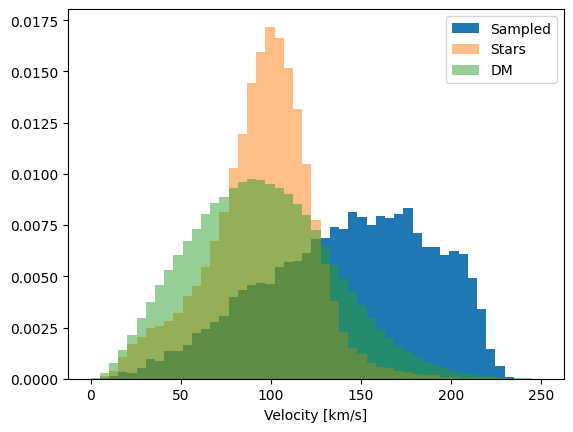

In [117]:
# Plot the resulting velocity distribution

bins = np.linspace(0, 250, 50)

fig,ax = plt.subplots()
_ = ax.hist(np.array(v_sampled)*exp_units['velocity'].to(u.km/u.s) , 
            bins=bins, 
            density=True, 
            label='Sampled')

# Compare with the speed distribution of the simulated stars
idx = stars['r'] > 10

v_sim = np.linalg.norm(np.array([stars[vi][idx] for vi in ['vx', 'vy', 'vz']]),axis=0)
_ = ax.hist(v_sim, 
            bins=bins, 
            alpha=0.5, 
            label='Stars', 
            density=True)

# Repeat with DM particles
dm = MW_sim.__load_part_data__(snap=90, PartType=1)
idx_dm = dm['r'] > 10

v_dm = np.linalg.norm(np.array([dm[vi][idx_dm] for vi in ['vx', 'vy', 'vz']]),axis=0)
_ = ax.hist(v_dm, 
            bins=bins, 
            alpha=0.5, 
            label='DM', 
            density=True)

ax.set_xlabel("Velocity [km/s]")

ax.legend()
